In [3]:
import os
from dotenv import load_dotenv
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

load_dotenv

key_file_path = os.environ.get("GCP_KEY_PATH")

client = bigquery.Client.from_service_account_json(
    key_file_path,
    project="quantum-echo-data-eng-prod"
)


In [4]:
query = """
    SELECT 
        customer_key, 
        gross_sales_amount,
        order_date
    FROM `quantum-echo-data-eng-prod.gold.fct_sales`
    WHERE order_date >= '2010-01-01'
"""

df = client.query(query).to_dataframe()


/Users/roelsomido/demo-database/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [9]:
df['order_date'] = pd.to_datetime(df['order_date'])

segment_summary = (
    df.groupby("customer_key", as_index=False)
    .agg(
        total_spending=("gross_sales_amount", "sum"),
        first_order=("order_date", "min"),
        last_order=("order_date", 'max')
    )
    # --- CTE 1 Step B: Add calculated column (lifespan_months) ---
    .assign(
        lifespan_months=lambda x: (
            (x["last_order"].dt.year - x["first_order"].dt.year) * 12
            + (x["last_order"].dt.month - x["first_order"].dt.month)
        ),
        # --- CTE 2 Step A: Add calculated column (customer_segment) ---
        # (Since this is ALSO a column calculation, you can put it inside the SAME .assign!) 
        customer_segment=lambda x: np.select(
            condlist=[
                (x["lifespan_months"] >= 12) & (x["total_spending"] > 5000),
                (x["lifespan_months"] >= 12) & (x["total_spending"] <= 5000),
            ],
            choicelist=["VIP", "Regular"],
            default="New"
        )    
    )
    .groupby("customer_segment", as_index=False)
    .agg(total_customers=("customer_key", "count"))
    .sort_values(by="total_customers", ascending=False)
)

segment_summary



,customer_segment,total_customers
0,New,14629
1,Regular,2200
2,VIP,1653


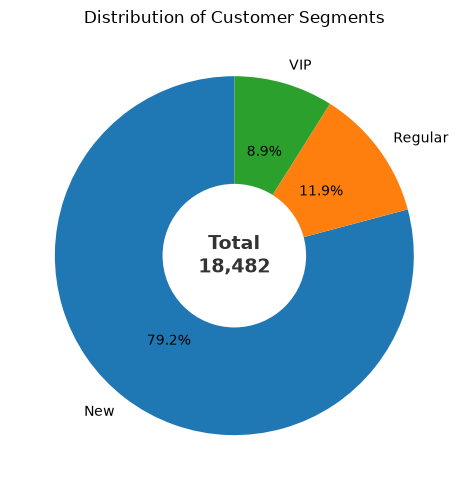

In [38]:
fig, ax = plt.subplots(figsize=(6,5))

# 1. Plot standard pie chart
segment_summary.plot(
    y='total_customers', 
    kind='pie', 
    ax=ax, 
    labels=segment_summary["customer_segment"],
    legend=False,
    startangle=90,
    autopct="%1.1f%%"
    )

# 2. Add white circle for donut hole
centre_circle = plt.Circle((0, 0), 0.40, fc='white')
ax.add_artist(centre_circle)

# 3. Calculate total customers
total_cust = segment_summary['total_customers'].sum()

# 4. Add centered text inside the donut hole
ax.text(
    0, 0,                             # Coordinates: (x=0, y=0) is exact center
    f"Total\n{total_cust:,.0f}",       # Main text string with line break
    ha='center',                       # Horizontal alignment
    va='center',                       # Vertical alignment
    fontsize=14, 
    fontweight='bold', 
    color='#333333'
)

ax.set_ylabel('')
ax.set_title("Distribution of Customer Segments")

plt.tight_layout()
plt.savefig("customer_segment.png", dpi=300, bbox_inches="tight")
plt.show()